In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("diabetes_data.csv", sep=";")
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})  # add this line
X = df.drop('class', axis=1)
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [20]:
y_pred = nb_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9423076923076923
              precision    recall  f1-score   support

           0       0.90      0.95      0.93        40
           1       0.97      0.94      0.95        64

    accuracy                           0.94       104
   macro avg       0.94      0.94      0.94       104
weighted avg       0.94      0.94      0.94       104



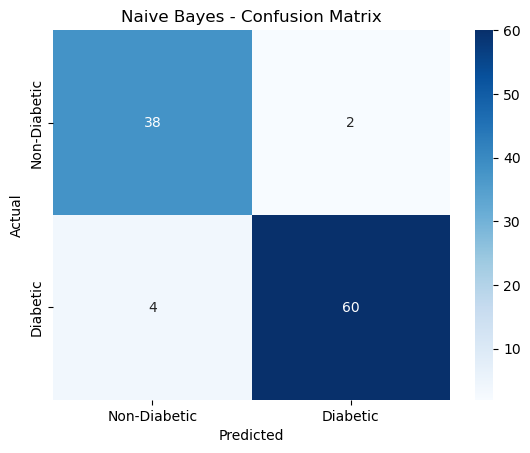

In [21]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Diabetic','Diabetic'],
            yticklabels=['Non-Diabetic','Diabetic'])
plt.title("Naive Bayes - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [22]:
cv_scores = cross_val_score(nb_model, X, y, cv=10, scoring='accuracy')
print("CV Scores:", cv_scores)
print(f"Mean CV Accuracy: {cv_scores.mean()*100:.2f}%")

CV Scores: [0.82692308 0.90384615 0.82692308 0.94230769 0.78846154 0.88461538
 0.88461538 0.94230769 0.92307692 0.88461538]
Mean CV Accuracy: 88.08%


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("="*40)
print("        PERFORMANCE METRICS")
print("="*40)
print(f"Accuracy  : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred)*100:.2f}%")
print(f"Recall    : {recall_score(y_test, y_pred)*100:.2f}%")
print(f"F1 Score  : {f1_score(y_test, y_pred)*100:.2f}%")
print("="*40)

        PERFORMANCE METRICS
Accuracy  : 94.23%
Precision : 96.77%
Recall    : 93.75%
F1 Score  : 95.24%


In [24]:
import joblib
import json
from sklearn.naive_bayes import GaussianNB

# train model
model = GaussianNB()
model.fit(X, y)

# save model
joblib.dump(model, "NB_model.pkl")

# save columns
json.dump(list(X.columns), open("columns.json", "w"))

print("Saved successfully")

Saved successfully
